In [1]:
import sys
from pathlib import Path
root = Path.cwd().parent
sys.path.append(str(root))

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from statsmodels.regression.linear_model import OLS
from statsmodels.tools import add_constant
from core.normalizer import compute_wallmid3

In [3]:
HP = "HYDROGEL_PACK"
VELVE = "VELVETFRUIT_EXTRACT"
VE40 = "VEV_4000"
VE45 = "VEV_4500"
VE50 = "VEV_5000"
VE51 = "VEV_5100"
VE52 = "VEV_5200"
VE53 = "VEV_5300"
VE54 = "VEV_5400"
VE55 = "VEV_5500"
VE60 = "VEV_6000"
VE65 = "VEV_6500"

products = {
    "HP": HP, "VELVE": VELVE,
    "VE40": VE40, "VE45": VE45, "VE50": VE50, "VE51": VE51,
    "VE52": VE52, "VE53": VE53, "VE54": VE54, "VE55": VE55,
    "VE60": VE60, "VE65": VE65
}

path = "/Users/alexoddsh/prosperity/backend/backtester/resources-4/round4/"

price_files = ["prices_round_4_day_1.csv", "prices_round_4_day_2.csv", "prices_round_4_day_3.csv"]
trade_files = ["trades_round_4_day_2.csv", "trades_round_4_day_2.csv", "trades_round_4_day_3.csv"]

df_list = [pd.read_csv(path + f, sep=";") for f in price_files]
tf_list = [pd.read_csv(path + f, sep=";") for f in trade_files]

all_dfs: dict[str, pd.DataFrame] = {}
all_tfs: dict[str, pd.DataFrame] = {}

for key, symbol in products.items():
    p_days = []
    for i, df in enumerate(df_list):
        sub = df[df["product"] == symbol].copy()
        if i > 0:
            sub["timestamp"] += i * 1000000
        sub["mid_price"] = sub["mid_price"].ffill()
        p_days.append(sub)
    
    combined_df = pd.concat(p_days)
    
    fill_cols = ["ask_price_1", "bid_price_1", "ask_price_2", "bid_price_2", "ask_price_3", "bid_price_3"]
    existing = [c for c in fill_cols if c in combined_df.columns]
    for col in existing:
        combined_df[col] = combined_df[col].ffill()
    
    all_dfs[key] = pd.DataFrame(combined_df)
    
    t_days = []
    for i, tf in enumerate(tf_list):
        sub_t = tf[tf["symbol"] == symbol].copy()
        if i > 0:
            sub_t["timestamp"] += i * 1000000
        t_days.append(sub_t)
    
    combined_tf = pd.concat(t_days)
    all_tfs[key] = pd.DataFrame(combined_tf)


df_hp: pd.DataFrame = all_dfs["HP"]
df_velve: pd.DataFrame = all_dfs["VELVE"]
df_ve40: pd.DataFrame = all_dfs["VE40"]
df_ve45: pd.DataFrame = all_dfs["VE45"]
df_ve50: pd.DataFrame = all_dfs["VE50"]
df_ve51: pd.DataFrame = all_dfs["VE51"]
df_ve52: pd.DataFrame = all_dfs["VE52"]
df_ve53: pd.DataFrame = all_dfs["VE53"]
df_ve54: pd.DataFrame = all_dfs["VE54"]
df_ve55: pd.DataFrame = all_dfs["VE55"]
df_ve60: pd.DataFrame = all_dfs["VE60"]
df_ve65: pd.DataFrame = all_dfs["VE65"]

tf_hp: pd.DataFrame = all_tfs["HP"]
tf_velve: pd.DataFrame = all_tfs["VELVE"]
tf_ve40: pd.DataFrame = all_tfs["VE40"]
tf_ve45: pd.DataFrame = all_tfs["VE45"]
tf_ve50: pd.DataFrame = all_tfs["VE50"]
tf_ve51: pd.DataFrame = all_tfs["VE51"]
tf_ve52: pd.DataFrame = all_tfs["VE52"]
tf_ve53: pd.DataFrame = all_tfs["VE53"]
tf_ve54: pd.DataFrame = all_tfs["VE54"]
tf_ve55: pd.DataFrame = all_tfs["VE55"]
tf_ve60: pd.DataFrame = all_tfs["VE60"]
tf_ve65: pd.DataFrame = all_tfs["VE65"]

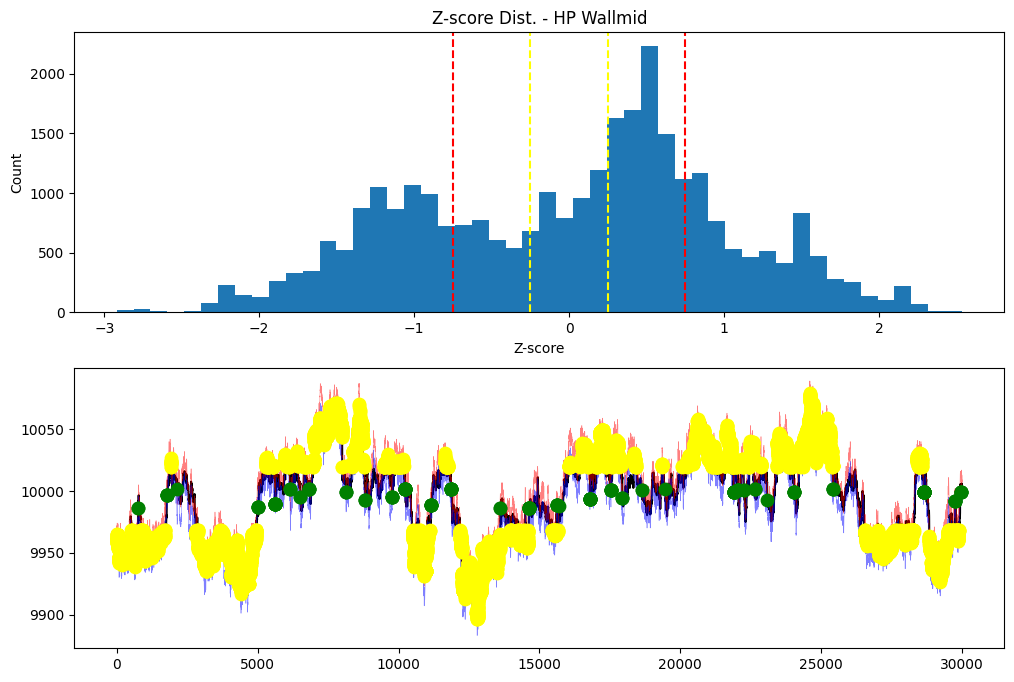

NULL HYPOTHESIS REJECTED: True
RHO: -0.0008723799738477968
PHI: 0.9991276200261522
REG EQUILIBRIUM: 9995.67044474948
T-STAT: -3.656912364085511
P-VAL: 0.004761698785088582
Half Life: 794.2007078239201
Mean Wallmid: 9993.93215
Std. Wallmid: 33.54066542649497
Z-Score Signals: 196


In [4]:
#Step 1/2 DF test
compute_wallmid3(HP, df_hp)
wallmid = df_hp["wallmid3"].ffill().bfill().to_numpy()
null_reject = False

#regression "c" -> variant 2 and "ct" = variant 3
#c for constant, t for trend
#Autolag=none means not augmented

t_stat, p_val, usedlag, nobs, critical_values = adfuller(wallmid, maxlag=0, regression="c", autolag=None) # type: ignore

if t_stat < critical_values["5%"]:
    null_reject = True

# Get Rho/Phi since adfuller doesnt extract it

#Note that this OLS will get RHO not PHI since we use delta y aka we have reparamaretized the original autoregression
#By subtracting y_{t-1} on both sides. Means the left side becomes delta Y and right side we use Rho = (Phi - 1) instead of
#Phi as the coefficient.

if null_reject:
    delta_y = np.diff(wallmid) #1st observation is dropped
    y_lag = wallmid[:-1] #1st observation is dropped
    X = add_constant(y_lag) #Just adds a column of ones so we have a 2D array where the 1s are used for the intercept alpha
    ols_res = OLS(delta_y, X).fit()
    intercept = ols_res.params[0]
    rho = ols_res.params[1]
    phi = rho + 1
    
    #Step 3 Check HL
    half_life = np.log(2) / -np.log(phi)

    #Step 4 check size and number of deviations and distribution
    mu_wallmid = wallmid.mean()
    sigma_wallmid = wallmid.std(ddof=1) #note delta degrees of freedom = 1 we want sample sigma!
    z_scores = (wallmid - mu_wallmid) / sigma_wallmid
    
    #check 
    above = np.abs(z_scores) > 0.75 #bool array
    crossings = np.diff(above.astype(int)) #convert bool array to 0,1s then do diff and we will have the crossings
    entry_crossings = np.where(crossings == 1)[0] +1 #because np diff drops one element

    entry_signals = np.sum(crossings == 1)
    entry_times = np.where(abs(z_scores) > 0.75)[0]

    exit_times = []
    for entry in entry_crossings:
        candidates = np.where(np.abs(z_scores[entry:]) < 0.25)[0]
        if len(candidates) > 0:
            exit_times.append(entry + candidates[0])

    exit_times = np.array(exit_times)

    fig, ax = plt.subplots(2 , 1, figsize=(12, 8))
    ax[0].hist(z_scores, bins=50)
    ax[0].set_title("Z-score Dist. - HP Wallmid")
    ax[0].axvline(x=0.75, color="red", linestyle="--")
    ax[0].axvline(x=-0.75, color="red", linestyle="--")
    ax[0].axvline(x=0.25, color="yellow", linestyle="--")
    ax[0].axvline(x=-0.25, color="yellow", linestyle="--")
    ax[0].set_xlabel("Z-score")
    ax[0].set_ylabel("Count")

    ax[1].plot(wallmid, color="black")
    ax[1].plot(df_hp["ask_price_1"].ffill().bfill().to_numpy(), color="red", linewidth=0.4, alpha=0.5)
    ax[1].plot(df_hp["bid_price_1"].ffill().bfill().to_numpy(), color="blue", linewidth=0.4, alpha=0.5)
    ax[1].scatter(entry_times, wallmid[entry_times], color="yellow", s=80, zorder=5, marker="o")
    ax[1].scatter(exit_times, wallmid[exit_times], color="green", s=80, zorder=5, marker="o")

    plt.show()

    print(f"NULL HYPOTHESIS REJECTED: {null_reject}")
    print(f"RHO: {rho}")
    print(f"PHI: {phi}")
    print(f"REG EQUILIBRIUM: {-intercept/rho}")
    
    print(f"T-STAT: {t_stat}")
    print(f"P-VAL: {p_val}")
    
    print(f"Half Life: {half_life}")
    print(f"Mean Wallmid: {mu_wallmid}")
    print(f"Std. Wallmid: {sigma_wallmid}")
    print(f"Z-Score Signals: {entry_signals}")
    

if not null_reject:
    print(f"NULL HYPOTHESIS REJECTED: {null_reject}")